In [20]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sms
import pandas as pd
%matplotlib inline
import seaborn as sns

In [21]:
import pandas as pd
df = pd.read_excel("/kaggle/input/datasets/mahiruddin/dusk-group-financial-data/Forecasting_dataset.xlsx", sheet_name="Monthly_Data_5Y")

In [22]:
df.head()

,Fiscal_Year,Month_Start,Month_End,YearMonth,Month_Number,Fiscal_Month_Number,Quarter,Company_Name,Currency,Data_Source_Type,...,AP_Turnover,Inventory_Turnover,Cash_Conversion_Cycle_Days,Debt_to_Equity_Ratio,Interest_Coverage_Ratio,Customer_Growth_MoM,Customer_Retention_Rate,Customer_Churn_Rate,Average_Revenue_per_Customer_AUD,Revenue_per_Employee_AUD
0,FY2021,2020-07-01,2020-07-31,2020-07,7,1,Q3,Dusk Group Limited,AUD '000,Synthetic monthly allocation anchored to annua...,...,0.397100,0.243864,48.355439,1.214797,15.296746,NaN,0.987576,0.012424,18.62,16253.12
1,FY2021,2020-08-01,2020-08-31,2020-08,8,2,Q3,Dusk Group Limited,AUD '000,Synthetic monthly allocation anchored to annua...,...,0.393829,0.242550,48.401990,1.207518,15.395358,0.015336,0.987767,0.012233,18.34,16253.12
2,FY2021,2020-09-01,2020-09-30,2020-09,9,3,Q3,Dusk Group Limited,AUD '000,Synthetic monthly allocation anchored to annua...,...,0.417894,0.226358,61.599465,1.200378,18.420693,0.017045,0.987952,0.012048,19.32,17414.06
3,FY2021,2020-10-01,2020-10-31,2020-10,10,4,Q4,Dusk Group Limited,AUD '000,Synthetic monthly allocation anchored to annua...,...,0.487039,0.269466,50.522980,1.193374,23.435940,0.020574,0.988154,0.011846,21.46,19735.94
4,FY2021,2020-11-01,2020-11-30,2020-11,11,5,Q4,Dusk Group Limited,AUD '000,Synthetic monthly allocation anchored to annua...,...,0.672323,0.382386,34.483779,1.186503,39.342259,0.031369,0.988392,0.011608,28.15,25892.42


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 73 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Fiscal_Year                                 60 non-null     object 
 1   Month_Start                                 60 non-null     object 
 2   Month_End                                   60 non-null     object 
 3   YearMonth                                   60 non-null     object 
 4   Month_Number                                60 non-null     int64  
 5   Fiscal_Month_Number                         60 non-null     int64  
 6   Quarter                                     60 non-null     object 
 7   Company_Name                                60 non-null     object 
 8   Currency                                    60 non-null     object 
 9   Data_Source_Type                            60 non-null     object 
 10  Revenue_AUD_000 

# Fixing Date Format

In [24]:
df["Month_Start"] = pd.to_datetime(df["Month_Start"])
df["Month_End"] = pd.to_datetime(df["Month_End"])
df = df.drop("YearMonth", axis=1)

In [25]:
df[["Fiscal_Year", "Month_Start", "Month_End"]].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Fiscal_Year  60 non-null     object        
 1   Month_Start  60 non-null     datetime64[ns]
 2   Month_End    60 non-null     datetime64[ns]
dtypes: datetime64[ns](2), object(1)
memory usage: 1.5+ KB


In [26]:
df.head()

,Fiscal_Year,Month_Start,Month_End,Month_Number,Fiscal_Month_Number,Quarter,Company_Name,Currency,Data_Source_Type,Revenue_AUD_000,...,AP_Turnover,Inventory_Turnover,Cash_Conversion_Cycle_Days,Debt_to_Equity_Ratio,Interest_Coverage_Ratio,Customer_Growth_MoM,Customer_Retention_Rate,Customer_Churn_Rate,Average_Revenue_per_Customer_AUD,Revenue_per_Employee_AUD
0,FY2021,2020-07-01,2020-07-31,7,1,Q3,Dusk Group Limited,AUD '000,Synthetic monthly allocation anchored to annua...,10402.0,...,0.397100,0.243864,48.355439,1.214797,15.296746,NaN,0.987576,0.012424,18.62,16253.12
1,FY2021,2020-08-01,2020-08-31,8,2,Q3,Dusk Group Limited,AUD '000,Synthetic monthly allocation anchored to annua...,10402.0,...,0.393829,0.242550,48.401990,1.207518,15.395358,0.015336,0.987767,0.012233,18.34,16253.12
2,FY2021,2020-09-01,2020-09-30,9,3,Q3,Dusk Group Limited,AUD '000,Synthetic monthly allocation anchored to annua...,11145.0,...,0.417894,0.226358,61.599465,1.200378,18.420693,0.017045,0.987952,0.012048,19.32,17414.06
3,FY2021,2020-10-01,2020-10-31,10,4,Q4,Dusk Group Limited,AUD '000,Synthetic monthly allocation anchored to annua...,12631.0,...,0.487039,0.269466,50.522980,1.193374,23.435940,0.020574,0.988154,0.011846,21.46,19735.94
4,FY2021,2020-11-01,2020-11-30,11,5,Q4,Dusk Group Limited,AUD '000,Synthetic monthly allocation anchored to annua...,17089.0,...,0.672323,0.382386,34.483779,1.186503,39.342259,0.031369,0.988392,0.011608,28.15,25892.42


# Filling Missing Values

In [27]:
df_null = df.isnull().sum()
print("Columns               Null Values")
for key in df.columns:
    if df_null[key] > 0:
        print(f"{key},      {df_null[key]}")

Columns               Null Values
Revenue_Growth_MoM,      1
Revenue_Growth_YoY,      12
Customer_Growth_MoM,      1


In [28]:
df[["Revenue_AUD_000", "Revenue_Growth_MoM"]].head()

,Revenue_AUD_000,Revenue_Growth_MoM
0,10402.0,NaN
1,10402.0,0.000000
2,11145.0,0.071429
3,12631.0,0.133333
4,17089.0,0.352941


In [29]:
df.fillna({"Revenue_Growth_MoM": df["Revenue_Growth_MoM"].mean()}, inplace=True)

In [30]:
df[["Revenue_AUD_000", "Customer_Growth_MoM"]].head()

,Revenue_AUD_000,Customer_Growth_MoM
0,10402.0,NaN
1,10402.0,0.015336
2,11145.0,0.017045
3,12631.0,0.020574
4,17089.0,0.031369


In [31]:
df.fillna({"Customer_Growth_MoM": df["Customer_Growth_MoM"].mean()}, inplace=True)

In [32]:
df[["Revenue_AUD_000", "Revenue_Growth_YoY"]].head(15)

,Revenue_AUD_000,Revenue_Growth_YoY
0,10402.00,NaN
1,10402.00,NaN
2,11145.00,NaN
3,12631.00,NaN
4,17089.00,NaN
5,23033.00,NaN
6,10402.00,NaN
7,8916.00,NaN
8,10402.00,NaN
9,11888.00,NaN


In [33]:
df.fillna({"Revenue_Growth_YoY": df["Revenue_Growth_YoY"].mean()}, inplace=True)

In [34]:
df_null = df.isnull().sum()
print("Columns               Null Values")
for key in df.columns:
    if df_null[key] > 0:
        print(f"{key},      {df_null[key]}")

Columns               Null Values


# Exploratory Data Analysis

## Finding Correlation with Revenue

In [35]:
corr_matrix = df[['Revenue_AUD_000', 'Store_Revenue_AUD_000',
       'Online_Revenue_AUD_000', 'Loyalty_Revenue_AUD_000',
       'Cost_of_Sales_AUD_000', 'Gross_Profit_AUD_000', 'Other_Income_AUD_000',
       'Employee_Benefit_Expense_AUD_000', 'Occupancy_Expense_AUD_000',
       'Advertising_Expense_AUD_000', 'Technology_Software_Expense_AUD_000',
       'Asset_Property_Maintenance_Expense_AUD_000',
       'Other_Operating_Expenses_AUD_000', 'Operating_Expenses_AUD_000',
       'EBITDA_AUD_000', 'Depreciation_Amortisation_AUD_000', 'EBIT_AUD_000',
       'Finance_Costs_AUD_000', 'Finance_Income_AUD_000',
       'Profit_Before_Tax_AUD_000', 'Tax_Expense_AUD_000',
       'Net_Profit_AUD_000', 'Cash_Balance_AUD_000',
       'Accounts_Receivable_AUD_000', 'Accounts_Payable_AUD_000',
       'Inventory_AUD_000', 'Current_Assets_AUD_000',
       'Current_Liabilities_AUD_000', 'Lease_Liabilities_Debt_AUD_000',
       'Equity_AUD_000', 'Operating_Cash_Flow_AUD_000', 'Capex_AUD_000',
       'Store_Count', 'Employee_Count_Estimated', 'Customer_Count_Estimated',
       'New_Customers_Estimated', 'Retained_Customers_Estimated',
       'Lost_Customers_Estimated', 'Transaction_Volume_Estimated',
       'Average_Order_Value_AUD', 'Gross_Profit_Margin', 'Net_Profit_Margin',
       'EBITDA_Margin', 'Operating_Expense_Ratio', 'Payroll_to_Revenue_Ratio',
       'Marketing_to_Revenue_Ratio', 'Revenue_Growth_MoM',
       'Revenue_Growth_YoY', 'Current_Ratio', 'Quick_Ratio',
       'Working_Capital_AUD_000', 'Days_Sales_Outstanding', 'AR_Turnover',
       'AP_Turnover', 'Inventory_Turnover', 'Cash_Conversion_Cycle_Days',
       'Debt_to_Equity_Ratio', 'Interest_Coverage_Ratio',
       'Customer_Growth_MoM', 'Customer_Retention_Rate', 'Customer_Churn_Rate',
       'Average_Revenue_per_Customer_AUD', 'Revenue_per_Employee_AUD']].corr()
corr_matrix

,Revenue_AUD_000,Store_Revenue_AUD_000,Online_Revenue_AUD_000,Loyalty_Revenue_AUD_000,Cost_of_Sales_AUD_000,Gross_Profit_AUD_000,Other_Income_AUD_000,Employee_Benefit_Expense_AUD_000,Occupancy_Expense_AUD_000,Advertising_Expense_AUD_000,...,AP_Turnover,Inventory_Turnover,Cash_Conversion_Cycle_Days,Debt_to_Equity_Ratio,Interest_Coverage_Ratio,Customer_Growth_MoM,Customer_Retention_Rate,Customer_Churn_Rate,Average_Revenue_per_Customer_AUD,Revenue_per_Employee_AUD
Revenue_AUD_000,1.000000,0.998843,0.930452,-0.126588,0.987713,0.995454,0.047070,0.616545,-0.036215,0.881225,...,0.950588,0.989037,-0.830995,0.082926,0.875233,0.797798,0.063282,-0.063287,0.948287,0.989000
Store_Revenue_AUD_000,0.998843,1.000000,0.911751,-0.114561,0.988133,0.993349,0.026806,0.623280,-0.037173,0.869754,...,0.956218,0.990630,-0.824829,0.072154,0.868077,0.788359,0.062539,-0.062544,0.944215,0.986683
Online_Revenue_AUD_000,0.930452,0.911751,1.000000,-0.208293,0.907113,0.933479,0.197751,0.516917,-0.026076,0.899552,...,0.833207,0.899394,-0.812849,0.158489,0.861161,0.807183,0.063985,-0.063989,0.905001,0.929141
Loyalty_Revenue_AUD_000,-0.126588,-0.114561,-0.208293,1.000000,0.008353,-0.207307,-0.335142,0.363635,0.179033,0.032553,...,0.096006,-0.134057,0.385348,-0.661098,-0.430719,-0.645452,-0.667081,0.667072,-0.395747,-0.251996
Cost_of_Sales_AUD_000,0.987713,0.988133,0.907113,0.008353,1.000000,0.968338,0.003236,0.693167,-0.019032,0.909695,...,0.969225,0.974408,-0.784404,-0.004597,0.803191,0.710980,0.004411,-0.004418,0.890785,0.954573
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Customer_Growth_MoM,0.797798,0.788359,0.807183,-0.645452,0.710980,0.841110,0.242516,0.236310,-0.183611,0.612802,...,0.613104,0.792353,-0.794173,0.421179,0.901791,1.000000,0.491585,-0.491583,0.920342,0.860667
Customer_Retention_Rate,0.063282,0.062539,0.063985,-0.667081,0.004411,0.098400,0.158929,-0.151606,-0.342508,-0.026059,...,-0.117434,0.083325,-0.275866,0.378608,0.198085,0.491585,1.000000,-1.000000,0.182998,0.118661
Customer_Churn_Rate,-0.063287,-0.062544,-0.063989,0.667072,-0.004418,-0.098405,-0.158902,0.151586,0.342487,0.026053,...,0.117424,-0.083328,0.275857,-0.378595,-0.198081,-0.491583,-1.000000,1.000000,-0.182999,-0.118665
Average_Revenue_per_Customer_AUD,0.948287,0.944215,0.905001,-0.395747,0.890785,0.971921,0.133650,0.425821,-0.085964,0.771384,...,0.841998,0.939522,-0.851172,0.267154,0.948562,0.920342,0.182998,-0.182999,1.000000,0.981116


In [63]:
corr_rev = corr_matrix["Revenue_AUD_000"]
corr_rev = {k: float(np.round(v, 2)) for k, v in corr_rev.items()}

corr_rev = sorted(corr_rev.items(), key=lambda item: item[1], reverse=True)
corr_rev

[('Revenue_AUD_000', 1.0),
 ('Store_Revenue_AUD_000', 1.0),
 ('Gross_Profit_AUD_000', 1.0),
 ('Cost_of_Sales_AUD_000', 0.99),
 ('Transaction_Volume_Estimated', 0.99),
 ('Inventory_Turnover', 0.99),
 ('Revenue_per_Employee_AUD', 0.99),
 ('Operating_Cash_Flow_AUD_000', 0.97),
 ('EBITDA_AUD_000', 0.95),
 ('Net_Profit_AUD_000', 0.95),
 ('AP_Turnover', 0.95),
 ('Average_Revenue_per_Customer_AUD', 0.95),
 ('Online_Revenue_AUD_000', 0.93),
 ('EBIT_AUD_000', 0.93),
 ('Profit_Before_Tax_AUD_000', 0.93),
 ('New_Customers_Estimated', 0.93),
 ('AR_Turnover', 0.93),
 ('Advertising_Expense_AUD_000', 0.88),
 ('Interest_Coverage_Ratio', 0.88),
 ('Customer_Growth_MoM', 0.8),
 ('Tax_Expense_AUD_000', 0.72),
 ('Net_Profit_Margin', 0.71),
 ('Operating_Expenses_AUD_000', 0.69),
 ('EBITDA_Margin', 0.67),
 ('Accounts_Receivable_AUD_000', 0.64),
 ('Employee_Benefit_Expense_AUD_000', 0.62),
 ('Revenue_Growth_MoM', 0.58),
 ('Marketing_to_Revenue_Ratio', 0.41),
 ('Average_Order_Value_AUD', 0.15),
 ('Accounts_Pay

<Axes: >

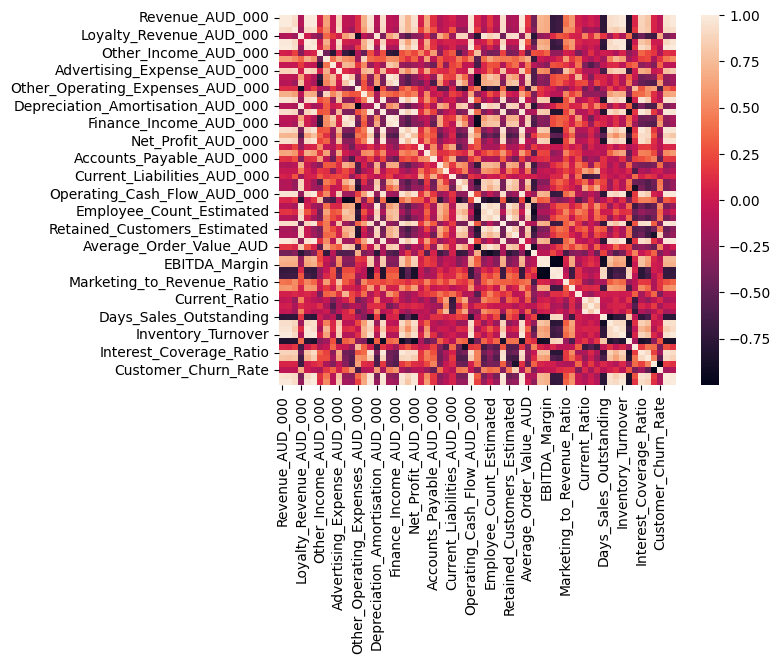

In [37]:
sns.heatmap(corr_matrix)

Text(0, 0.5, 'Revenue_AUD_000')

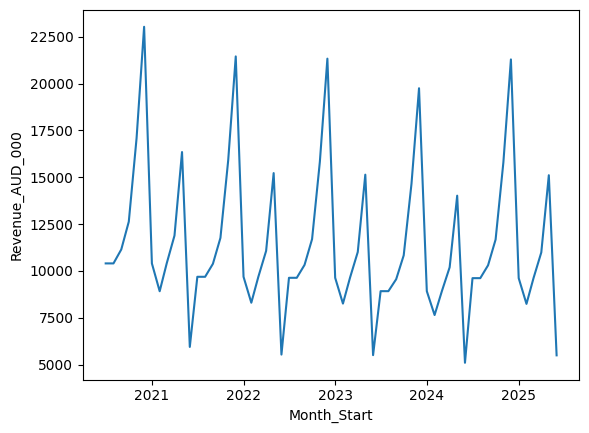

In [64]:
plt.plot(df["Month_Start"], df["Revenue_AUD_000"])
plt.xlabel("Month_Start")
plt.ylabel("Revenue_AUD_000")

Highly Seasonal Data

Text(0, 0.5, 'Store_Revenue_AUD_000')

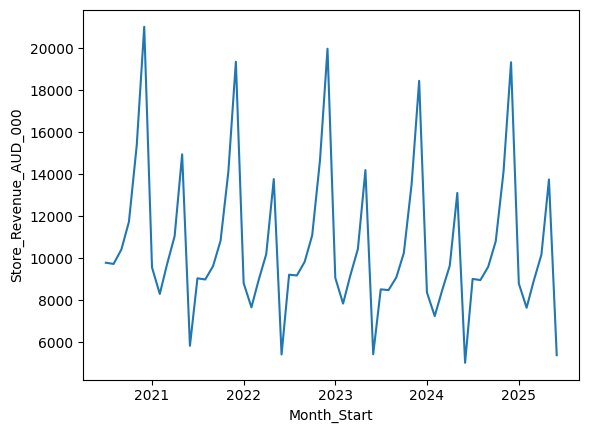

In [65]:
plt.plot(df["Month_Start"], df["Store_Revenue_AUD_000"])
plt.xlabel("Month_Start")
plt.ylabel("Store_Revenue_AUD_000")

Text(0, 0.5, 'Online_Revenue_AUD_000')

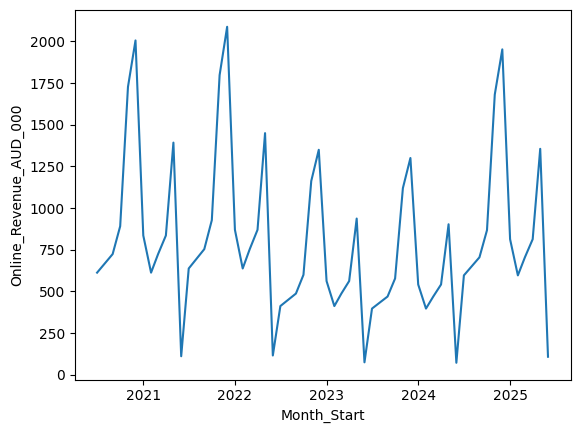

In [66]:
plt.plot(df["Month_Start"], df["Online_Revenue_AUD_000"])
plt.xlabel("Month_Start")
plt.ylabel("Online_Revenue_AUD_000")

Highly Seasonal Data

# Forecasting with Sarima

In [67]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from sklearn.metrics import mean_absolute_error, mean_squared_error

In [77]:
df.set_index('Month_Start', inplace = True)

In [82]:
df = df.sort_index()
df_rev = df["Revenue_AUD_000"]
df_rev.head()

Month_Start
2020-07-01    10402.0
2020-08-01    10402.0
2020-09-01    11145.0
2020-10-01    12631.0
2020-11-01    17089.0
Name: Revenue_AUD_000, dtype: float64

In [79]:
def adf_test(series):
    result=adfuller(series)
    print('ADF Statistics: {}'.format(result[0]))
    print('p- value: {}'.format(result[1]))
    if result[1] <= 0.05:
        print("strong evidence against the null hypothesis, reject the null hypothesis. Data has no unit root and is stationary")
    else:
        print("weak evidence against null hypothesis, time series has a unit root, indicating it is non-stationary ")

In [83]:
adf_test(df_rev)

ADF Statistics: -2.7934333918362126
p- value: 0.059217900765658214
weak evidence against null hypothesis, time series has a unit root, indicating it is non-stationary 


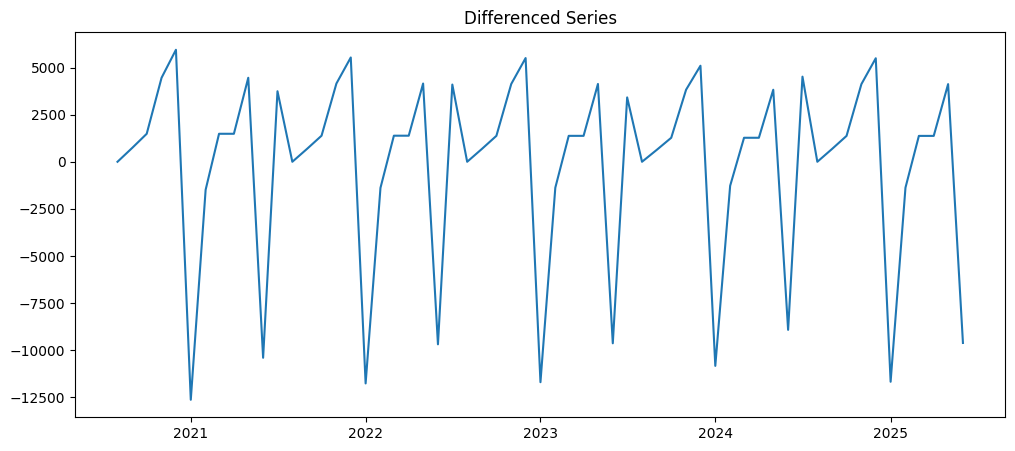

In [85]:
df_rev_diff = df_rev.diff().dropna()

plt.figure(figsize=(12,5))
plt.plot(df_rev_diff)
plt.title("Differenced Series")
plt.show()

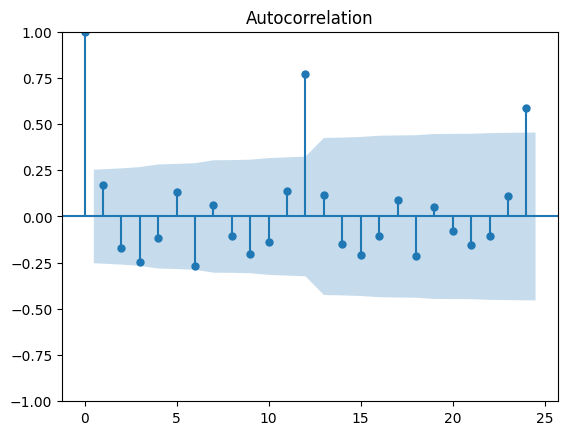

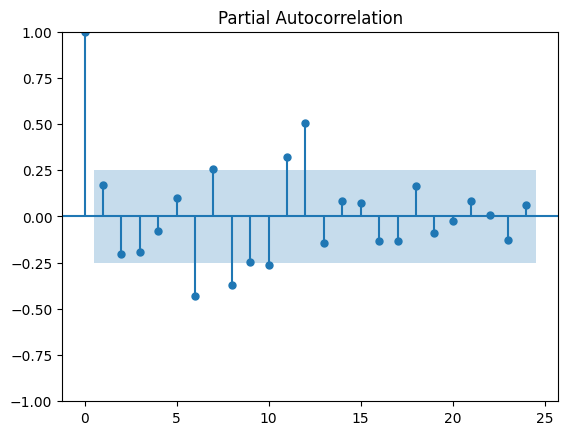

In [88]:
plot_acf(df_rev, lags=24)
plot_pacf(df_rev, lags=24)
plt.show()

In [89]:
p, d, q = 1, 1, 1
P, D, Q, s = 1, 1, 1, 12

In [90]:
train = df_rev.iloc[:48]
test = df_rev.iloc[48:]

In [94]:
model = SARIMAX(train,
                order=(p, d, d),
                seasonal_order=(P, D, Q, s),
                enforce_stationarity=False,
                enforce_invertibility=False)

result = model.fit()

print(result.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


                                     SARIMAX Results                                      
Dep. Variable:                    Revenue_AUD_000   No. Observations:                   48
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -149.599
Date:                            Wed, 29 Apr 2026   AIC                            309.198
Time:                                    15:51:12   BIC                            314.421
Sample:                                07-01-2020   HQIC                           310.332
                                     - 06-01-2024                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7223      0.171      4.219      0.000       0.387       1.058
ma.L1         -1.0000      0.446   

In [95]:
forecast = result.get_forecast(steps=len(test))

forecast_mean = forecast.predicted_mean
conf_int = forecast.conf_int()

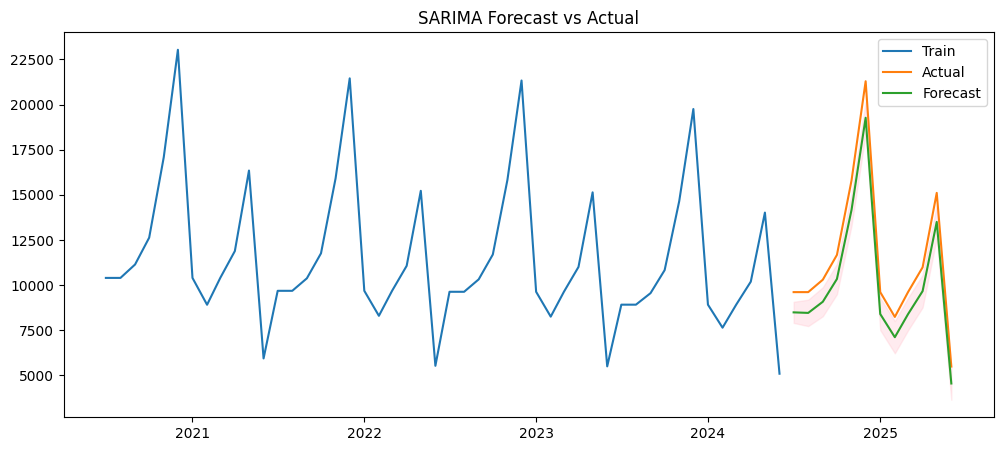

In [97]:
plt.figure(figsize=(12,5))

plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Actual')
plt.plot(test.index, forecast_mean, label='Forecast')

plt.fill_between(test.index,
                 conf_int.iloc[:,0],
                 conf_int.iloc[:,1],
                 color='pink', alpha=0.3)

plt.legend()
plt.title("SARIMA Forecast vs Actual")
plt.show()

In [100]:
mae = mean_absolute_error(test, forecast_mean)
rmse = np.sqrt(mean_squared_error(test, forecast_mean))

mape = np.mean(np.abs((test - forecast_mean) / test)) * 100

print("MAE:", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

MAE: 1324.62384207517
RMSE: 1354.332028713664
MAPE: 12.111321608872395


In [101]:
final_model = SARIMAX(df['Revenue_AUD_000'],
                      order=(1,1,1),
                      seasonal_order=(1,1,1,12),
                      enforce_stationarity=False,
                      enforce_invertibility=False)

final_result = final_model.fit()

future_forecast = final_result.get_forecast(steps=12)

future_mean = future_forecast.predicted_mean
future_conf = future_forecast.conf_int()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


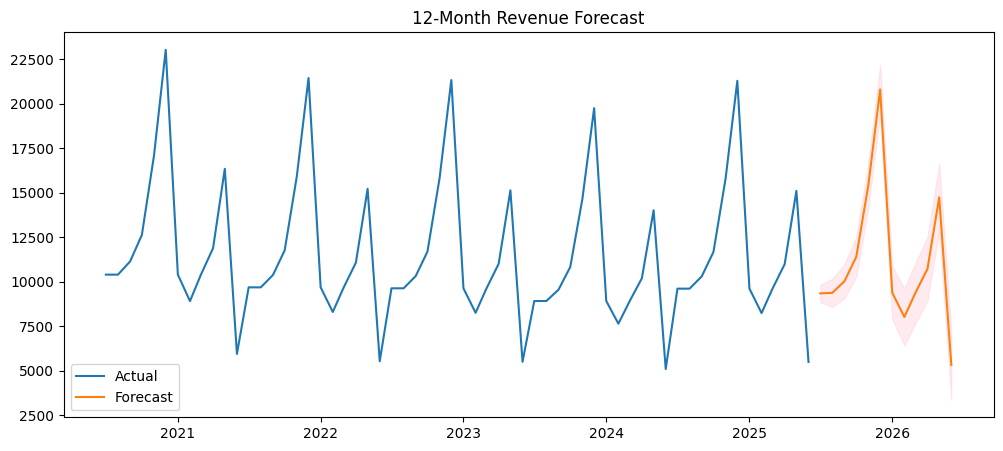

In [102]:
plt.figure(figsize=(12,5))

plt.plot(df.index, df['Revenue_AUD_000'], label='Actual')
plt.plot(future_mean.index, future_mean, label='Forecast')

plt.fill_between(future_mean.index,
                 future_conf.iloc[:,0],
                 future_conf.iloc[:,1],
                 color='pink', alpha=0.3)

plt.legend()
plt.title("12-Month Revenue Forecast")
plt.show()